## Full S2E simulation demo

This notebook shows how to run a full start-to-end FACET-II simulation

In [ ]:
import FACET2_S2E as qs
from pathlib import Path
import os

#Load a reference configuration
filepath = str(Path(os.getcwd()).parent)
importedDefaultSettings = qs.loadConfig("/setLattice_configs/2024-10-22_oneBunch_baseline3.yml",filepath)


tao = qs.initializeTao(
    #Overall settings
    filePath=filepath,
    inputBeamFilePathSuffix = importedDefaultSettings["inputBeamFilePathSuffix"],
    scratchPath = "/tmp",
    randomizeFileNames = True,

    #Overriding settings for the Bmad parts of the run
    csrTF = False, #Disabling CSR for faster execution

    #Overriding settings for the IMPACT-T part of the run; settings give a low fidelity but faster demonstration
    runImpactTF = True,
    numMacroParticles = int(1e4),
    impactChargepC = 1800,
    impactGridCount = 8,

    #Settings for the QPAD part of the run
    runQPAD= True,
    setQPADDefaultsFile = "qpad/2025-08-20-QPAD_defaults.yml",
)

# Set up lattice
qs.setLattice(tao, **importedDefaultSettings)

# Complete start-to-end tracking
qs.trackBeam(tao, filepath=filepath, plasmaSIM=True, **importedDefaultSettings)

# Save beam before and after plasma
P_before = qs.getBeamAtElement(tao, "PENT")
P_after = qs.getBeamAtElement(tao, "PEXT")



Environment set to:  /Users/nmajik/Documents/SLAC/FACET2-S2E
-init /Users/nmajik/Documents/SLAC/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
CSR off
Overwriting lattice with setLattice() defaults
No defaults file provided to setLattice(). Using /Users/nmajik/Documents/SLAC/FACET2-S2E/setLattice_configs/defaults.yml
Running Impact
	 Impact: Autophasing
	 Impact: Distgen
	 Impact: Tracking
Running Impact-T in /Users/nmajik/Documents/SLAC/FACET2-S2E/impact/tmpoihoajjk
/opt/homebrew/anaconda3/envs/bmad-qpad/bin/ImpactTexe
writing 10000 particles to /Users/nmajik/Documents/SLAC/FACET2-S2E/impact/tmpoihoajjk/partcl.data
Cathode start with cathode_kinetic_energy_ref = 1.0 eV
Cathode start: Replaced Np with 10000 according to initial particles
Cathode start: Replaced Bkenergy with 1.0 according to initial particles
Cathode start: Replaced Temission with 6.97502773839391e-12 according to initial particles
Cathode start: Replaced Tini with -3.4942219079267073e-12 according to initial particle

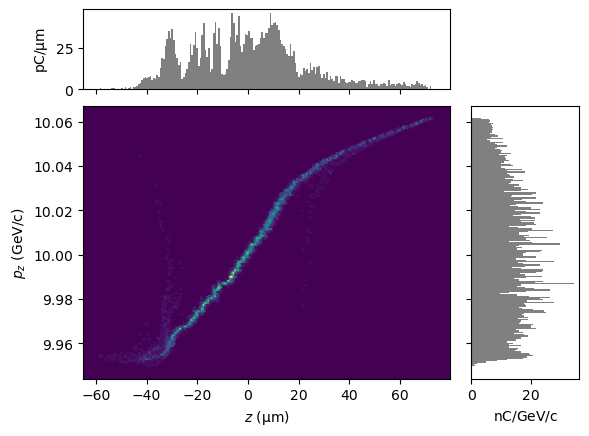

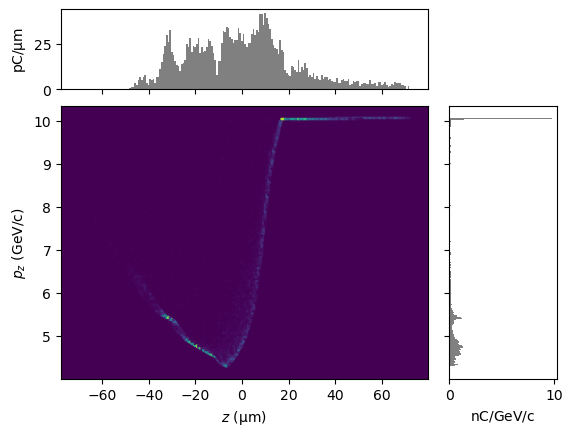

In [ ]:
# Plot the longitudinal phase space before and after plasma
display(qs.plotMod(P_before, 'z', 'pz',  bins=200));
display(qs.plotMod(P_after, 'z', 'pz',  bins=200));